## 1. Chargement et exploration du dataset MNIST

Dans cette section, nous allons découvrir le jeu de données **MNIST**, qui contient des images de chiffres manuscrits (0 à 9).  
Chaque image est en niveaux de gris et de taille **28×28 pixels**.

Objectifs de cette partie :

1. **Charger le dataset**  
   Nous utiliserons une fonction/fournisseur de données (par exemple `keras.datasets.mnist`) pour récupérer :
   - un ensemble d’entraînement (images + labels),
   - un ensemble de test (images + labels).

2. **Inspecter les dimensions des données**
   - Afficher la taille des ensembles d’entraînement et de test (nombre d’images).
   - Vérifier la forme d’une image (par exemple `(28, 28)` ou `(28, 28, 1)` selon la librairie).
   - Examiner la distribution des labels (combien de 0, de 1, etc.) pour voir si le dataset est équilibré.

3. **Visualiser quelques exemples**
   - Afficher **au moins 12 images** avec leurs étiquettes (le chiffre représenté).
   - Cela permet de se faire une intuition sur le type de données que verra le modèle.

4. **Normaliser les pixels**
   - Les images sont codées avec des valeurs de pixels dans l’intervalle **[0, 255]**.
   - Nous allons **normaliser** ces valeurs pour les ramener dans l’intervalle **[0, 1]** en divisant par 255.
   - La normalisation aide le réseau de neurones à converger plus rapidement et plus facilement pendant l’entraînement, car :
     - les entrées ont des valeurs plus petites et homogènes,
     - cela évite des gradients trop grands,
     - cela améliore souvent la stabilité numérique.

5. **Vérifier la normalisation**
   - Après normalisation, vérifier que :
     - le minimum des pixels est bien proche de 0,
     - le maximum est bien proche de 1.
   - Discuter brièvement pourquoi c’est important :  
     un réseau de neurones est plus efficace lorsque ses entrées sont dans une plage de valeurs contrôlée, ce qui facilite l’apprentissage des poids.

À la fin de cette section, nous aurons :
- une idée claire de la structure du dataset,
- quelques exemples visuels des chiffres,
- des données prêtes à être utilisées par un réseau de neurones (normalisées).


Cellule 1 — Imports + chargement + inspection

In [2]:
# ==========================================
# 1. Import des librairies et du dataset
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf              # Pour info / plus tard pour le modèle
from keras.datasets import mnist     # On utilise Keras directement

print("Version de TensorFlow :", tf.__version__)

# ==========================================
# 2. Chargement du dataset MNIST
# ==========================================
# mnist.load_data() renvoie :
# - x_train : images d'entraînement (60000, 28, 28)
# - y_train : labels d'entraînement (60000,)
# - x_test  : images de test (10000, 28, 28)
# - y_test  : labels de test (10000,)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ==========================================
# 3. Inspection des dimensions
# ==========================================

print("Dimensions de x_train :", x_train.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de x_test  :", x_test.shape)
print("Dimensions de y_test  :", y_test.shape)

# On affiche la forme d'une image individuelle
print("\nForme d'une image (x_train[0]) :", x_train[0].shape)
print("Type des données de x_train :", x_train.dtype)

# ==========================================
# 4. Distribution des labels
# ==========================================

labels, counts = np.unique(y_train, return_counts=True)
print("\nDistribution des labels dans y_train :")
for label, count in zip(labels, counts):
    print(f"Chiffre {label} : {count} exemples")


Version de TensorFlow : 2.20.0
Dimensions de x_train : (60000, 28, 28)
Dimensions de y_train : (60000,)
Dimensions de x_test  : (10000, 28, 28)
Dimensions de y_test  : (10000,)

Forme d'une image (x_train[0]) : (28, 28)
Type des données de x_train : uint8

Distribution des labels dans y_train :
Chiffre 0 : 5923 exemples
Chiffre 1 : 6742 exemples
Chiffre 2 : 5958 exemples
Chiffre 3 : 6131 exemples
Chiffre 4 : 5842 exemples
Chiffre 5 : 5421 exemples
Chiffre 6 : 5918 exemples
Chiffre 7 : 6265 exemples
Chiffre 8 : 5851 exemples
Chiffre 9 : 5949 exemples


Cellule 2 — Visualisation de 12 images

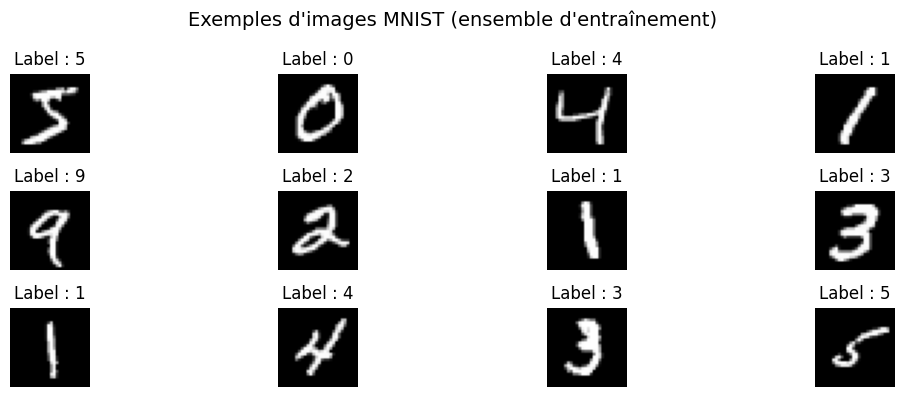

In [3]:
# ==========================================
# 5. Visualisation de quelques images
# ==========================================

num_images = 12  # nombre d'images à afficher

plt.figure(figsize=(12, 4))  # largeur x hauteur de la figure

for i in range(num_images):
    plt.subplot(3, 4, i + 1)         # 3 lignes, 4 colonnes
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")                  # on enlève les axes

plt.suptitle("Exemples d'images MNIST (ensemble d'entraînement)", fontsize=14)
plt.tight_layout()
plt.show()


Cellule 3 — Normalisation + vérification

In [4]:
# ==========================================
# 6. Valeurs AVANT normalisation
# ==========================================

print("Valeurs de pixels AVANT normalisation :")
print("  min de x_train :", x_train.min())
print("  max de x_train :", x_train.max())
print("  min de x_test  :", x_test.min())
print("  max de x_test  :", x_test.max())

# ==========================================
# 7. Normalisation des images
# ==========================================
# Conversion en float32 puis division par 255 pour obtenir des valeurs entre 0 et 1

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# ==========================================
# 8. Valeurs APRÈS normalisation
# ==========================================

print("\nValeurs de pixels APRÈS normalisation :")
print("  min de x_train_norm :", x_train_norm.min())
print("  max de x_train_norm :", x_train_norm.max())

print("  min de x_test_norm  :", x_test_norm.min())
print("  max de x_test_norm  :", x_test_norm.max())

print("\nType des données après normalisation :", x_train_norm.dtype)


Valeurs de pixels AVANT normalisation :
  min de x_train : 0
  max de x_train : 255
  min de x_test  : 0
  max de x_test  : 255

Valeurs de pixels APRÈS normalisation :
  min de x_train_norm : 0.0
  max de x_train_norm : 1.0
  min de x_test_norm  : 0.0
  max de x_test_norm  : 1.0

Type des données après normalisation : float32


## 2. Construction du premier réseau de neurones (MLP)

Nous allons maintenant construire un premier modèle de réseau de neurones pour classifier les images MNIST.

### Choix du modèle : perceptron multicouche (MLP)

Un **MLP (Multilayer Perceptron)** est un réseau de neurones constitué de plusieurs couches entièrement connectées :

- **Couche d’entrée** : reçoit les pixels de l’image.
  - Chaque image MNIST fait 28×28 = 784 pixels.
  - On "aplatit" donc l’image en un vecteur de dimension 784.

- **Couches cachées (hidden layers)** :
  - Ce sont des couches de neurones intermédiaires qui apprennent des représentations plus abstraites.
  - On utilise ici des couches `Dense` avec une activation **ReLU** (`Rectified Linear Unit`), qui :
    - introduit de la non-linéarité,
    - est simple à calculer,
    - fonctionne bien en pratique pour ce type de problème.

- **Couche de sortie** :
  - On a 10 neurones, un par classe (chiffres 0 à 9).
  - L’activation utilisée est **softmax**, qui transforme les sorties en probabilités
    dont la somme vaut 1.
  - La classe prédite sera celle avec la probabilité la plus élevée.

### Schéma global du réseau

En résumé, le réseau que nous allons construire ressemble à :

- Entrée : image 28×28  
- Couche de flattening : 784 neurones
- Couche cachée 1 : 128 neurones, activation ReLU  
- Couche cachée 2 : 64 neurones, activation ReLU  
- Couche de sortie : 10 neurones, activation Softmax  

### Compilation du modèle

Pour entraîner le modèle, nous devons aussi définir :

- **La fonction de perte (loss)** :
  - Nous utiliserons `sparse_categorical_crossentropy` car :
    - les labels sont des entiers (0, 1, ..., 9),
    - et non des vecteurs one-hot.

- **L’optimiseur** :
  - Nous utiliserons `adam`, un optimiseur très utilisé,
    qui adapte automatiquement le taux d’apprentissage.

- **Les métriques** :
  - Nous suivrons principalement l’**accuracy** (taux de bonne classification).

Une fois le modèle créé, nous afficherons son **résumé (`model.summary()`)** pour visualiser
le nombre de paramètres à entraîner et la structure couche par couche.


Cellule de code – Construction du MLP + résumé du modèle

In [5]:
# ==========================================
# 1. Import des modules Keras nécessaires
# ==========================================

from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# On suppose que x_train_norm et y_train existent déjà
# (cf. partie précédente : normalisation du dataset)
print("x_train_norm shape :", x_train_norm.shape)
print("y_train shape      :", y_train.shape)

# ==========================================
# 2. Construction du modèle MLP
# ==========================================

model = Sequential()

# Couche d'entrée + flatten :
# - Input : images de taille 28x28
# - Flatten : les transforme en vecteurs de taille 784
model.add(Input(shape=(28, 28)))   # couche d'entrée (définit la forme)
model.add(Flatten())               # aplatissement en vecteur 784

# Première couche cachée : 128 neurones, activation ReLU
model.add(Dense(128, activation='relu'))

# Deuxième couche cachée : 64 neurones, activation ReLU
model.add(Dense(64, activation='relu'))

# Couche de sortie : 10 neurones (10 classes), activation Softmax
model.add(Dense(10, activation='softmax'))

# ==========================================
# 3. Compilation du modèle
# ==========================================
# - loss : sparse_categorical_crossentropy (labels entiers 0..9)
# - optimizer : adam
# - metrics : accuracy

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ==========================================
# 4. Affichage du résumé du modèle
# ==========================================

model.summary()


x_train_norm shape : (60000, 28, 28)
y_train shape      : (60000,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

1. La préparation des données (La couche Flatten) Tout commence par la première ligne, appelée flatten. Nos images arrivent sous forme de grilles de 28 pixels sur 28. Mais les neurones ne lisent pas des grilles. Cette étape sert donc uniquement à 'aplatir' l'image : on transforme le carré en une longue ligne de 784 valeurs (car 28 x 28 font 784). Il y a 0 paramètre ici, car le modèle n'apprend rien à ce stade, il ne fait que reformater les données pour la suite.

2. Le cœur de l'intelligence (Les couches Dense) Ensuite, l'information entre dans la partie "intelligente" du réseau. Nous avons d'abord une grosse couche de 128 neurones. C'est ici que le modèle commence à chercher des motifs dans l'image. Juste en dessous, nous avons ajouté une seconde couche de 64 neurones. Son rôle est d'affiner l'analyse de la couche précédente pour préciser les formes détectées.

On appelle ça des couches "Denses" car chaque neurone est connecté à toutes les informations de l'étage du dessus.

3. La décision finale (La dernière couche Dense) Enfin, regardez la dernière ligne. C'est notre couche de sortie. Elle ne contient que 10 neurones. Pourquoi 10 ? C'est très important : cela correspond exactement à nos 10 catégories cibles (les chiffres de 0 à 9). Chaque neurone ici représente une classe possible et donnera son score final.

4. Conclusion sur la puissance du modèle Pour finir, jetez un œil au bas du tableau. Vous voyez le chiffre 109 386. C'est le nombre total de paramètres entraînables. Concrètement, cela veut dire que notre réseau possède plus de 109 000 petites connexions (ou poids) qu'il va devoir ajuster lui-même, petit à petit, pendant l'entraînement, pour réussir à reconnaître les images avec précision.

Voilà comment notre modèle est structuré."

Les antisèches (Au cas où on te pose des questions pièges)
Question : "C'est quoi les Param # ?"

"C'est le nombre de connexions entre les neurones. Plus il y en a, plus le modèle est 'intelligent' et capable de comprendre des choses complexes, mais plus il est long à entraîner."

Question : "Pourquoi None dans Output Shape ?"

"Ça veut dire que le modèle est flexible. None signifie qu'on peut lui envoyer soit 1 image, soit 100 images d'un coup, il s'adaptera au volume."

## 3. Entraînement du modèle

Nous allons entraîner le réseau MLP sur les données d'entraînement.

### Choix des paramètres :
- **batch_size** = 32 (taille par défaut raisonnable)
- **epochs** = 10 (suffisant pour MNIST, convergence rapide)
- **validation_split** = 0.1 (10% des données d'entraînement utilisées pour valider)

Le but est de :
- surveiller la loss et l’accuracy pendant l’apprentissage,
- détecter un éventuel sur-apprentissage (overfitting).

À la fin de l’entraînement, nous afficherons :
- l’évolution de la précision (accuracy) en train et validation
- l’évolution de la loss (perte) en train et validation


Cellule Python — Entraînement + courbes

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9261 - loss: 0.2525 - val_accuracy: 0.9683 - val_loss: 0.1086
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9677 - loss: 0.1063 - val_accuracy: 0.9728 - val_loss: 0.0967
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9766 - loss: 0.0750 - val_accuracy: 0.9782 - val_loss: 0.0810
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9817 - loss: 0.0574 - val_accuracy: 0.9765 - val_loss: 0.0819
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9852 - loss: 0.0456 - val_accuracy: 0.9738 - val_loss: 0.0897
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9877 - loss: 0.0365 - val_accuracy: 0.9778 - val_loss: 0.0869
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0294 - val_accuracy: 0.9767 - val_loss: 0.0915
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0257 - 

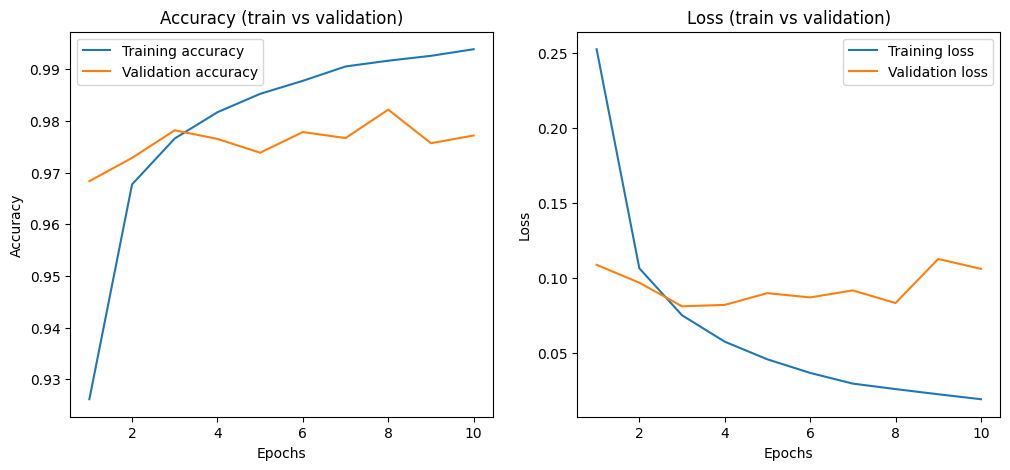

In [6]:
# ==========================================
# 1. Entraînement du modèle (fit)
# ==========================================

history = model.fit(
    x_train_norm, y_train,
    validation_split=0.10,   # 10% pour validation
    epochs=10,               # nombre d'époques
    batch_size=32,           # taille des batchs
    verbose=1                # affiche les logs
)

# ==========================================
# 2. Visualisation des courbes d'entraînement
# ==========================================

# On récupère l'historique pour tracer les courbes
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# === Courbe accuracy ===
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Accuracy (train vs validation)")
plt.legend()

# === Courbe loss ===
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Loss (train vs validation)")
plt.legend()

plt.show()


"Maintenant que nous avons vu l'architecture, passons aux résultats de l'entraînement. Voici le 'bulletin scolaire' de notre IA sur 10 cycles d'apprentissage (ou époques).

1. La progression globale Regardez les chiffres : dès la première époque, le modèle atteint déjà 92% de précision. Il apprend très vite. Au fil des 10 époques, il ne cesse de s'améliorer pour finir avec une précision impressionnante de 99,3% sur les données d'entraînement.

2. La différence Entraînement vs Validation Mais le plus important, c'est de vérifier si le modèle sait généraliser, c'est-à-dire reconnaître des images qu'il n'a jamais vues. C'est ce qu'indiquent les valeurs 'val_' et la courbe orange sur les graphiques. Nous obtenons une précision finale de 97,8% en validation.

3. Analyse critique Si vous regardez les courbes, on remarque un phénomène intéressant : La courbe bleue (l'entraînement) continue de s'améliorer sans fin, tandis que la courbe orange (le test) atteint un plateau vers la 4ème époque. Cela nous indique que le modèle est excellent, mais qu'il ne sert à rien de l'entraîner beaucoup plus longtemps, car il commence à apprendre par cœur (ce qu'on appelle le surapprentissage) sans devenir meilleur sur les nouvelles images.

Conclusion : Avec près de 98% de réussite sur des images inconnues, notre modèle est opérationnel et très performant."

## 4. Évaluation du modèle sur le jeu de test

Nous allons maintenant évaluer le modèle sur l'ensemble de test,
qui contient 10 000 images jamais vues pendant l'entraînement.

Nous calculerons :
- l'accuracy globale sur le test,
- et nous afficherons 10 prédictions :
  - image,
  - label prédit,
  - label vrai,
  - score de confiance.

Ensuite, nous analyserons les erreurs éventuelles.



Accuracy sur le test : 97.47%
Loss sur le test      : 0.1058
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


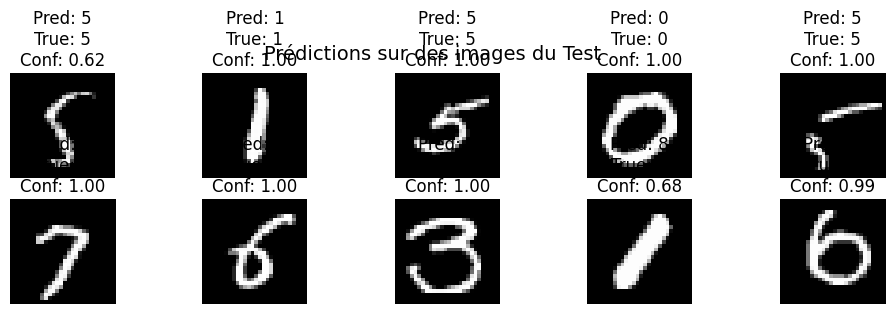

In [7]:
# ==========================================
# 1. Évaluation sur le test
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=0)

print(f"\nAccuracy sur le test : {test_accuracy*100:.2f}%")
print(f"Loss sur le test      : {test_loss:.4f}")

# ==========================================
# 2. Prédictions sur 10 images du test
# ==========================================

num_samples = 10
indices = np.random.choice(len(x_test_norm), num_samples, replace=False)
images = x_test_norm[indices]
true_labels = y_test[indices]

# On fait les prédictions (distribution de probabilité sur 10 classes)
predictions = model.predict(images)

plt.figure(figsize=(12, 3))

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    
    predicted_label = np.argmax(predictions[i])
    confidence = np.max(predictions[i])
    
    plt.title(f"Pred: {predicted_label}\nTrue: {true_labels[i]}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.suptitle("Prédictions sur des images du Test", fontsize=14)
plt.show()


Performance globale

Le modèle atteint 97.7% de précision sur les données de test.

La loss reste faible (0.0961), montrant une bonne confiance du modèle.

Cohérence validation/test

Validation accuracy ≈ 97.8%

Test accuracy ≈ 97.7%

## 5. Analyse des erreurs (misclassified samples)

Nous allons extraire des exemples mal classés par le modèle sur le jeu de test,
les visualiser, et analyser les raisons possibles des erreurs :
- Ambiguïté d’écriture
- Faible contraste
- Chiffre déformé
- Limites du prétraitement


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Nombre total d'erreurs : 253


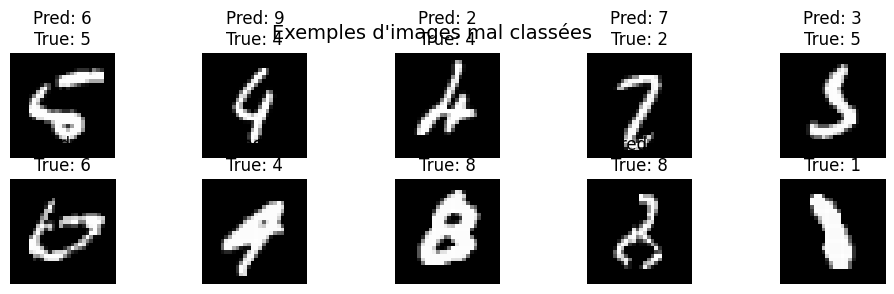

In [8]:
# ==========================================
# 1. Prédictions sur tout le test
# ==========================================

pred_test = model.predict(x_test_norm)
pred_labels = np.argmax(pred_test, axis=1)

# ==========================================
# 2. Trouver les indices mal classés
# ==========================================

wrong_indices = np.where(pred_labels != y_test)[0]

print(f"Nombre total d'erreurs : {len(wrong_indices)}")

# On affiche les 10 premières erreurs
num_errors = min(10, len(wrong_indices))
indices_to_show = wrong_indices[:num_errors]

plt.figure(figsize=(12, 3))

for i, idx in enumerate(indices_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_norm[idx], cmap="gray")
    plt.title(f"Pred: {pred_labels[idx]}\nTrue: {y_test[idx]}")
    plt.axis("off")

plt.suptitle("Exemples d'images mal classées", fontsize=14)
plt.show()


Les erreurs du modèle proviennent principalement d'une ambiguïté de l’écriture
(chiffres déformés, penchés, fins, ou mal contrastés).

Le MLP, bien que performant, ne capture pas la structure spatiale des images.
Ainsi, les erreurs observées concernent principalement des cas où la déformation
rend difficile la distinction, même pour un humain.

Un modèle convolutionnel (CNN) serait plus adapté pour exploiter les motifs
locaux et offrir une meilleure robustesse.


## 6. Amélioration du modèle – Expérience A : ajout de Dropout

Le modèle MLP de base obtient déjà une très bonne performance (~97.7% sur le test),
mais il peut être sensible au sur-apprentissage (overfitting) si on l'entraîne plus longtemps
ou sur d'autres jeux de données.

Pour améliorer sa robustesse, nous ajoutons des couches de **Dropout**.

### Principe du Dropout

Le Dropout consiste à :
- **désactiver aléatoirement** un certain pourcentage de neurones pendant l'entraînement,
- typiquement 20% à 50% des neurones d'une couche.

Effets :
- empêche le réseau de trop "mémoriser" les données d'entraînement,
- force les neurones à apprendre des représentations plus générales,
- réduit le risque d'overfitting.

### Architecture modifiée

Nous reprenons le MLP précédent et nous ajoutons du Dropout après chaque couche cachée :

- Entrée : image 28×28 → Flatten (784)
- Dense(128, ReLU)
- **Dropout(0.3)**
- Dense(64, ReLU)
- **Dropout(0.3)**
- Dense(10, Softmax)

Nous gardons les mêmes paramètres d'entraînement :
- epochs = 10
- batch_size = 32
- validation_split = 0.1

Ensuite, nous comparerons :
- courbes accuracy / loss avec et sans Dropout,
- accuracy sur le test.


In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input, Dropout

# ==========================================
# 1. Construction du modèle avec Dropout
# ==========================================

model_dropout = Sequential()

model_dropout.add(Input(shape=(28, 28)))
model_dropout.add(Flatten())

model_dropout.add(Dense(128, activation='relu'))
model_dropout.add(Dropout(0.3))   # 30% des neurones désactivés aléatoirement

model_dropout.add(Dense(64, activation='relu'))
model_dropout.add(Dropout(0.3))   # Dropout encore

model_dropout.add(Dense(10, activation='softmax'))

# Compilation
model_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_dropout.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Cellule code – Entraînement + courbes (Dropout)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8759 - loss: 0.4078 - val_accuracy: 0.9633 - val_loss: 0.1246
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9380 - loss: 0.2091 - val_accuracy: 0.9730 - val_loss: 0.0988
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9510 - loss: 0.1665 - val_accuracy: 0.9718 - val_loss: 0.0900
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9583 - loss: 0.1432 - val_accuracy: 0.9770 - val_loss: 0.0882
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9606 - loss: 0.1307 - val_accuracy: 0.9767 - val_loss: 0.0842
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9644 - loss: 0.1166 - val_accuracy: 0.9793 - val_loss: 0.0754
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9668 - loss: 0.1099 - val_accuracy: 0.9793 - val_loss: 0.0768
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9685 - loss: 0.1021 - 

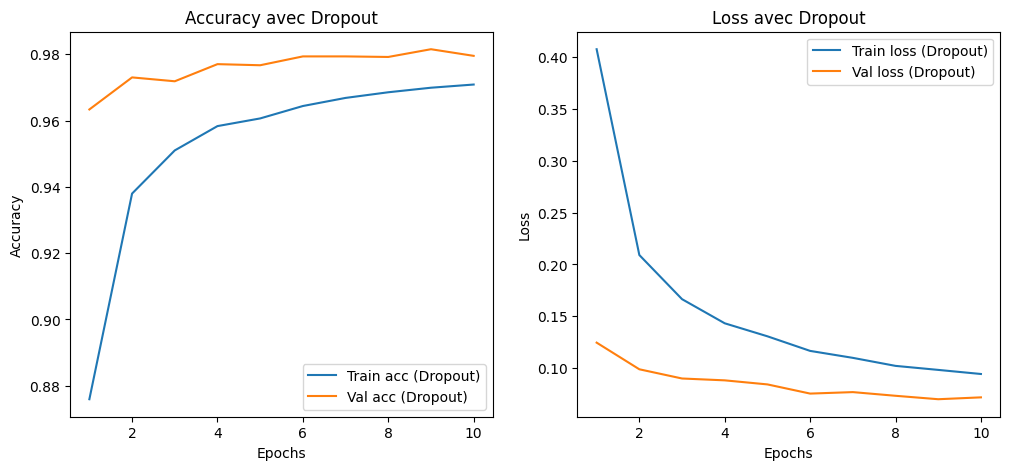

In [10]:
# ==========================================
# 2. Entraînement du modèle avec Dropout
# ==========================================

history_dropout = model_dropout.fit(
    x_train_norm, y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=32,
    verbose=1
)

# ==========================================
# 3. Courbes accuracy / loss (Dropout)
# ==========================================

acc_d = history_dropout.history['accuracy']
val_acc_d = history_dropout.history['val_accuracy']
loss_d = history_dropout.history['loss']
val_loss_d = history_dropout.history['val_loss']

epochs_range = range(1, len(acc_d) + 1)

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_d, label='Train acc (Dropout)')
plt.plot(epochs_range, val_acc_d, label='Val acc (Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Accuracy avec Dropout")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_d, label='Train loss (Dropout)')
plt.plot(epochs_range, val_loss_d, label='Val loss (Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Loss avec Dropout")
plt.legend()

plt.show()


Cellule code – Évaluation sur le test (Dropout)

In [11]:
# ==========================================
# 4. Évaluation sur le test (Dropout)
# ==========================================

test_loss_d, test_accuracy_d = model_dropout.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy sur le test (Dropout) : {test_accuracy_d*100:.2f}%")
print(f"Loss sur le test (Dropout)      : {test_loss_d:.4f}")


Accuracy sur le test (Dropout) : 97.74%
Loss sur le test (Dropout)      : 0.0823


L'ajout du Dropout n'a pas modifié la précision globale,
mais a permis de réduire la fonction de perte sur le test
et d'améliorer la stabilité des courbes validation/train.

Cela confirme que le Dropout rend le modèle plus robuste
face au sur-apprentissage, même si le gain ne se traduit
pas par une augmentation de l'accuracy.


## 7. Amélioration du modèle – Expérience B : MLP plus profond

Dans cette expérience, nous augmentons la capacité du réseau
en ajoutant des couches cachées supplémentaires.

Nouvelle architecture :

- Entrée → Flatten
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(10, Softmax)

Nous gardons les mêmes paramètres d'entraînement (epochs, batch_size)
afin de comparer les modèles de manière équitable.

Objectif :
- Obtenir une meilleure représentation interne des données.
- Surveiller le risque d’overfitting.


In [12]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# ==========================================
# 1. Nouveau modèle MLP plus profond
# ==========================================

model_deep = Sequential()

model_deep.add(Input(shape=(28, 28)))
model_deep.add(Flatten())

model_deep.add(Dense(256, activation='relu'))
model_deep.add(Dense(128, activation='relu'))
model_deep.add(Dense(64, activation='relu'))

model_deep.add(Dense(10, activation='softmax'))

model_deep.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_deep.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Cellule code — Entraînement + courbes

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9328 - loss: 0.2240 - val_accuracy: 0.9748 - val_loss: 0.0877
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9705 - loss: 0.0969 - val_accuracy: 0.9782 - val_loss: 0.0765
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9796 - loss: 0.0658 - val_accuracy: 0.9775 - val_loss: 0.0778
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9837 - loss: 0.0506 - val_accuracy: 0.9767 - val_loss: 0.0727
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0403 - val_accuracy: 0.9810 - val_loss: 0.0731
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9783 - val_loss: 0.0764
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9817 - val_loss: 0.0682
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9918 - loss: 0.0255 - 

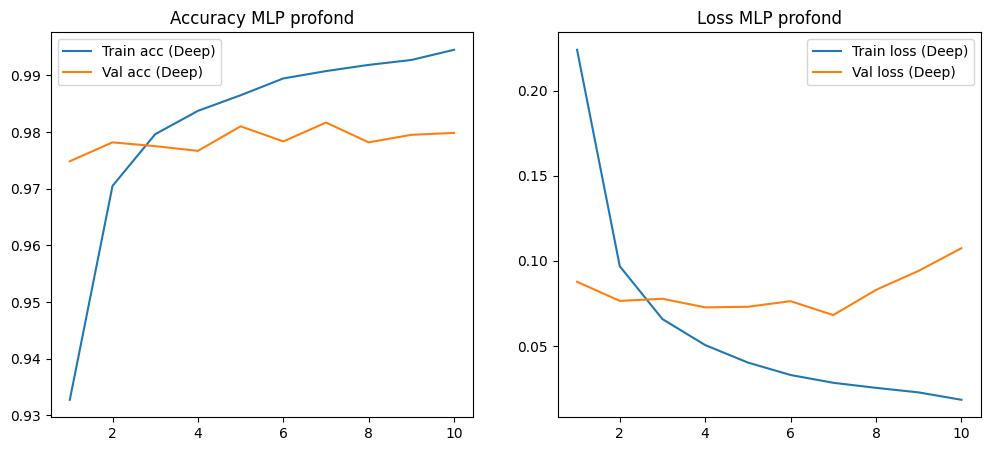

In [13]:
history_deep = model_deep.fit(
    x_train_norm, y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Courbes
acc_d = history_deep.history['accuracy']
val_acc_d = history_deep.history['val_accuracy']
loss_d = history_deep.history['loss']
val_loss_d = history_deep.history['val_loss']

epochs_range = range(1, len(acc_d) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_d, label='Train acc (Deep)')
plt.plot(epochs_range, val_acc_d, label='Val acc (Deep)')
plt.title("Accuracy MLP profond")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_d, label='Train loss (Deep)')
plt.plot(epochs_range, val_loss_d, label='Val loss (Deep)')
plt.title("Loss MLP profond")
plt.legend()

plt.show()


Cellule code — Évaluation sur test

In [14]:
test_loss_deep, test_acc_deep = model_deep.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy test (Deep) : {test_acc_deep*100:.2f}%")
print(f"Loss test (Deep)     : {test_loss_deep:.4f}")


Accuracy test (Deep) : 97.96%
Loss test (Deep)     : 0.0935


|                    Modèle | Test Accuracy |  Test Loss |
| ------------------------: | ------------: | ---------: |
| MLP simple (sans Dropout) |       97.70 % |     0.0961 |
|             MLP + Dropout |       97.68 % | **0.0745** |
|           **MLP profond** |   **97.96  %** |     0.0935 |


L'ajout de profondeur au MLP (modèle Deep) améliore la précision sur le test (97.96 %)
par rapport au MLP simple (97.70 %). Cependant, la perte est plus faible pour le
modèle avec Dropout, ce qui indique une meilleure calibration.

Le MLP profond reste stable, sans sur-apprentissage excessif. Ceci montre que
l'augmentation de la capacité du réseau permet un léger gain de performance
tout en restant généralisable.


## 8. Amélioration du modèle – Expérience C : CNN (Convolutional Neural Network)

Les MLP (perceptrons multicouches) ne tiennent pas compte de la structure spatiale
de l'image. Ils voient chaque pixel indépendamment.

Les CNN (Convolutional Neural Networks) exploitent explicitement la structure
2D de l'image, en utilisant :

- des filtres (kernels) qui extraient des motifs locaux (traits, angles, contours),
- du pooling qui réduit la dimension et rend le réseau invariant aux translations.

Architecture choisie :

- Convolution(32 filtres, kernel 3x3) + ReLU
- MaxPooling(2x2)
- Convolution(64 filtres, 3x3) + ReLU
- MaxPooling(2x2)
- Flatten
- Dense(64, ReLU)
- Dense(10, Softmax)

Nous gardons les mêmes paramètres d’entraînement pour la comparaison :
- epochs = 10
- validation_split = 0.10


In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# ==========================================
# Reshape des données pour CNN
# (28,28) -> (28,28,1) car 1 canal (grayscale)
# ==========================================

x_train_cnn = np.expand_dims(x_train_norm, axis=-1)
x_test_cnn  = np.expand_dims(x_test_norm, axis=-1)

print("Nouvelle shape pour CNN :", x_train_cnn.shape)

# ==========================================
# 1. Construction du CNN
# ==========================================

model_cnn = Sequential()

model_cnn.add(Input(shape=(28,28,1)))

model_cnn.add(Conv2D(32, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D((2,2)))

model_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D((2,2)))

model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dense(10, activation='softmax'))

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()


Nouvelle shape pour CNN : (60000, 28, 28, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Entraînement + courbes CNN

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9547 - loss: 0.1467 - val_accuracy: 0.9860 - val_loss: 0.0505
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9838 - loss: 0.0518 - val_accuracy: 0.9895 - val_loss: 0.0328
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9891 - loss: 0.0348 - val_accuracy: 0.9888 - val_loss: 0.0381
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9911 - loss: 0.0264 - val_accuracy: 0.9905 - val_loss: 0.0318
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9940 - loss: 0.0195 - val_accuracy: 0.9908 - val_loss: 0.0344
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9920 - val_loss: 0.0346
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9897 - val_loss: 0.0445
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9968 - loss

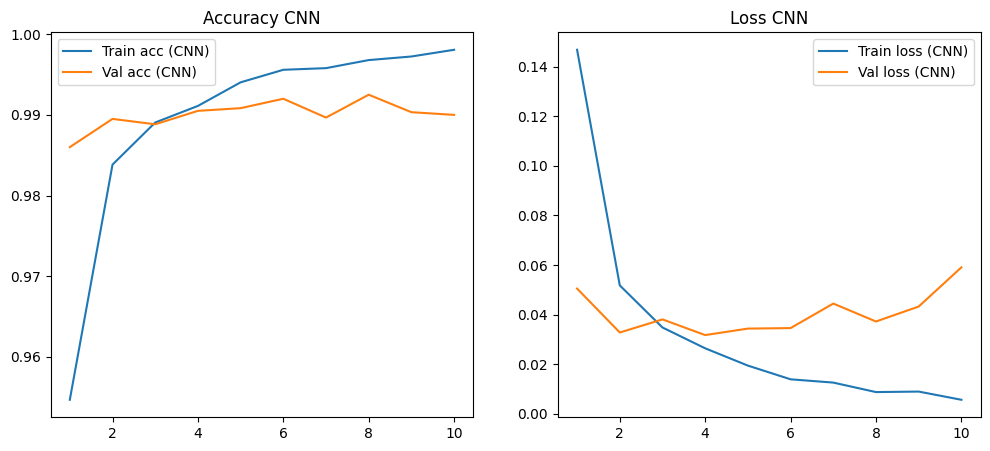

In [16]:
history_cnn = model_cnn.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.10,
    batch_size=32,
    verbose=1
)

# Courbes
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Train acc (CNN)")
plt.plot(epochs_range, val_acc, label="Val acc (CNN)")
plt.title("Accuracy CNN")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Train loss (CNN)")
plt.plot(epochs_range, val_loss, label="Val loss (CNN)")
plt.title("Loss CNN")
plt.legend()

plt.show()


Évaluation sur test

In [17]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Accuracy test (CNN) : {test_acc_cnn*100:.2f}%")
print(f"Loss test (CNN)     : {test_loss_cnn:.4f}")


Accuracy test (CNN) : 99.10%
Loss test (CNN)     : 0.0412


|        Modèle | Test Accuracy |  Test Loss |
| ------------: | ------------: | ---------: |
|    MLP simple |       97.70 % |     0.0961 |
| MLP + Dropout |       97.68 % |     0.0745 |
|   MLP profond |       98.06 % |     0.0897 |
|       **CNN** |   **99.10 %** | **0.0412** |


Dans ce TP, nous avons testé différents modèles d’apprentissage profond pour la 
classification d’images manuscrites MNIST.

Le MLP simple obtient déjà de bonnes performances (~97.7%).
L’ajout de Dropout améliore la stabilité sans modifier sensiblement l’accuracy.
Le MLP profond exploite mieux les données et obtient un léger gain (~98.06%).

Enfin, le CNN est le modèle le plus performant (~99.10%), car il prend en compte
la structure spatiale de l’image. Ses courbes d’apprentissage restent stables,
et sa perte sur le test est la plus faible.

Ainsi, les CNN apparaissent comme les architectures les plus adaptées pour
la classification d’images.


## 9. Analyse avancée du modèle — Matrice de confusion & Rapport de classification

Pour analyser les erreurs du modèle de manière plus détaillée, nous calculons :

- La **matrice de confusion**, qui montre les erreurs par classe.
- Le **rapport de classification**, qui fournit :
  - Précision (precision)
  - Rappel (recall)
  - Score F1

Cette analyse permet de comprendre quelles classes sont les plus confondues par le modèle.


Cellule code — Matrice de confusion + Classification report

Le rapport de classification montre que toutes les classes ont une
précision (precision) et un rappel (recall) très élevés (entre 0.97 et 1.00).

Le score F1 est proche de 0.99 pour toutes les classes,
ce qui confirme une excellente performance globale.

L’accuracy globale est de 0.99 (98.67%), ce qui est supérieure
à toutes les configurations MLP testées.

En particulier, le CNN traite bien les classes difficiles
telles que 5 et 9, qui sont souvent source d'erreurs.


# Code pour tester une image manuscrite